# Exercise 1 Static vs Contextual Embeddings
In this assignment, you will explore the differences between static word embeddings and contextual embeddings using the BERT model. You will extract embeddings from different layers, apply t-SNE visualization, and analyze how meaning shifts with context.
### Tasks:
1. Load BERT tokenizer and model  
2. Prepare a list of example sentences  
3. Extract static embeddings (embedding layer)  
4. Extract contextual embeddings (final hidden layer)  
5. Run t-SNE on both sets of embeddings  
6. Visualize and compare the representations prepare this for the presentation in the exercise.  
7. Research if/when the static and contextual embeddings are still comparable to each other.  

##### Deliverables: A notebook with embedding extraction, visualizations, analysis and interpretation.  


#### Load BERT tokenizer and model

In [162]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [163]:
import torch
from transformers import BertModel

In [ ]:
# Load the pre-trained BERT model
model = BertModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [165]:
from transformers import BertTokenizer
 
# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

#### Example Sentences

In [166]:
sentence1 = "Hello, how are you?"
sentence2 = "I am fine, thank you!"
sentence3= "The dog is barking loudly."
sentence4= "The cat is sleeping peacefully."
sentence5= "The sun is shining brightly."
sentence6= "The rain is pouring heavily."
sentence7= "The wind is blowing strongly."
sentence8= "The flowers are blooming beautifully."
sentence9= "The birds are singing melodiously."
sentence10= "The river is flowing gently."

#### Extract static embeddings (embedding layer)  
***Source:*** https://mccormickml.com/2019/05/14/BERT-word-embeddings-tutorial/#1-loading-pre-trained-bert

In [167]:
tokenized_text = [tokenizer.tokenize(sentence) for sentence in [sentence1, sentence2, sentence3, sentence4, sentence5, sentence6, sentence7, sentence8, sentence9, sentence10]]
tokenized_text = [token for sublist in tokenized_text for token in sublist]  # flatten
indexed_tokens = tokenizer.convert_tokens_to_ids(tokenized_text)

In [168]:
segments_ids = [1] * len(tokenized_text)

print (segments_ids)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [169]:
# Convert inputs to PyTorch tensors
tokens_tensor = torch.tensor([indexed_tokens])
segments_tensors = torch.tensor([segments_ids])

In [170]:
# Load pre-trained model (weights)
model = BertModel.from_pretrained('bert-base-uncased',
                                  output_hidden_states = True, # Whether the model returns all hidden-states.
                                  )

# Put the model in "evaluation" mode, meaning feed-forward operation.
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [171]:
# Run the text through BERT, and collect all of the hidden states produced
# from all 12 layers. 
with torch.no_grad():

    outputs = model(tokens_tensor, segments_tensors)

    # Evaluating the model will return a different number of objects based on 
    # how it's  configured in the `from_pretrained` call earlier. In this case, 
    # becase we set `output_hidden_states = True`, the third item will be the 
    # hidden states from all layers. See the documentation for more details:
    # https://huggingface.co/transformers/model_doc/bert.html#bertmodel
    hidden_states = outputs[2]

In [172]:
# Static embeddings = layer 0 (the embedding layer)
static_embeddings = hidden_states[0].squeeze(0).numpy()

#### Extract contextual embeddings (final hidden layer) 

In [173]:
print ("Number of layers:", len(hidden_states), "  (initial embeddings + 12 BERT layers)")
layer_i = 0

print ("Number of batches:", len(hidden_states[layer_i]))
batch_i = 0

print ("Number of tokens:", len(hidden_states[layer_i][batch_i]))
token_i = 0

print ("Number of hidden units:", len(hidden_states[layer_i][batch_i][token_i]))

Number of layers: 13   (initial embeddings + 12 BERT layers)
Number of batches: 1
Number of tokens: 64
Number of hidden units: 768


In [174]:
# Contextual embeddings = last hidden layer (layer 12)
contextual_embeddings = hidden_states[-1].squeeze(0).numpy()

#### Running t-SNE

**AI Use:** Claude  
*Prompt:* Using tsne give me the code to plot both the hidden and the static next to each other

In [175]:
import numpy as np
from sklearn.manifold import TSNE

def get_tsne(embeddings):
    pca = PCA(n_components=50)
    embeddings_pca = pca.fit_transform(embeddings)
    tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
    return tsne.fit_transform(embeddings_pca)

# Run t-SNE on both
static_tsne = get_tsne(static_embeddings)
contextual_tsne = get_tsne(contextual_embeddings)

##### Visualize and compare the representations prepare this for the presentation in the exercise

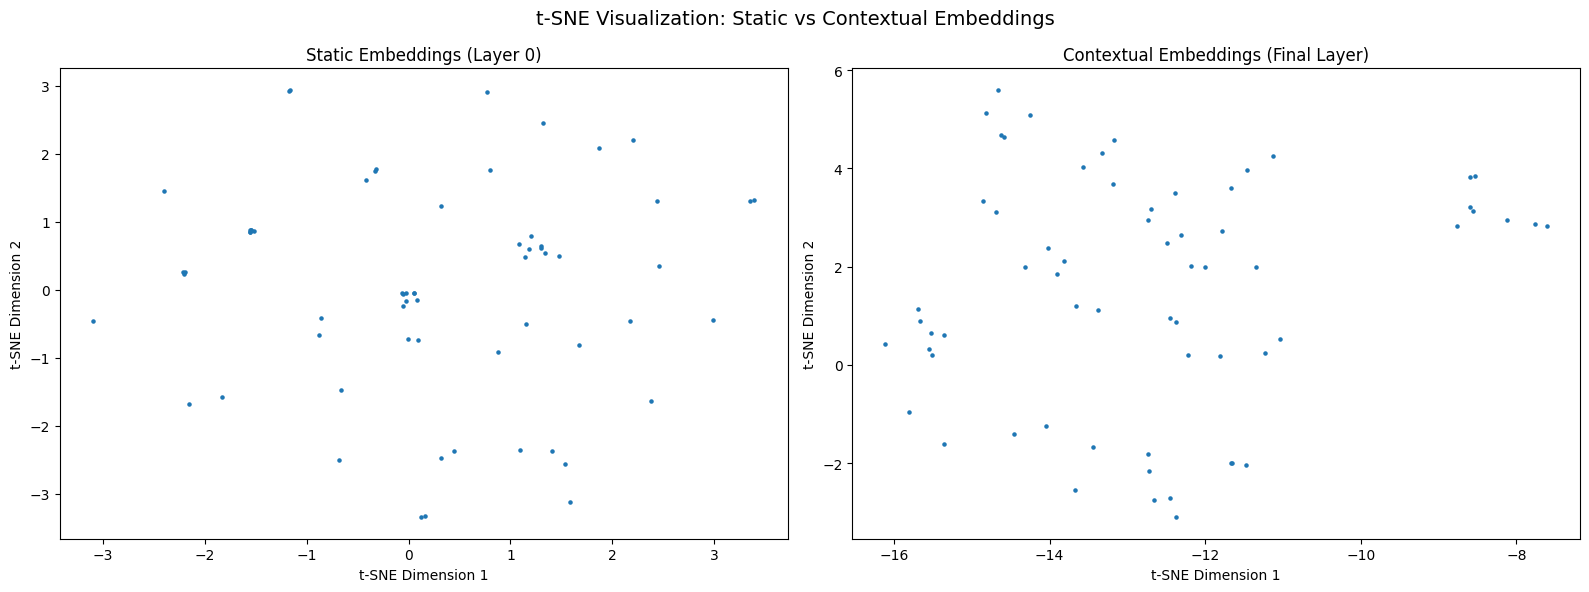

In [176]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(static_tsne[:, 0], static_tsne[:, 1], s=5)
axes[0].set_title("Static Embeddings (Layer 0)")
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")

axes[1].scatter(contextual_tsne[:, 0], contextual_tsne[:, 1], s=5)
axes[1].set_title("Contextual Embeddings (Final Layer)")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

plt.suptitle("t-SNE Visualization: Static vs Contextual Embeddings", fontsize=14)
plt.tight_layout()
plt.show()

#### **Research if/when the static and contextual embeddings are still comparable to each other**

# Exercise 2 Semantic Search and Retrieval Using Embeddings
In this final exercise, you will build a semantic search system using multiple embedding types
and evaluate retrieval quality. This demonstrates how embeddings enable downstream tasks
beyond classification.
### Task Description: You will implement semantic search using:
• Word2Vec (static embeddings)  
• BERT mean-pooled contextual embeddings  
• Sentence-BERT (SBERT) sentence embeddings  
### Steps:
1. Load or create a small text corpus (FAQ-like statements)  
2. Generate embeddings using all three methods  
3. Implement cosine-similarity-based retrieval  
4. Rank documents for a user query  
5. Evaluate with:  
• Precision@k  
• Recall@k  
• Mean Reciprocal Rank (MRR)  
6. Visualize embeddings using t-SNE  
##### Deliverables:
• Notebook containing all embedding methods  
• Retrieval system implementation  
• Evaluation metrics and t-SNE visualization  
• Discussion of results for the presentation: What are the limits of this approach?  


### Imports

In [177]:
pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [178]:
from gensim.models import Word2Vec
import gensim
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt_tab')
import warnings

warnings.filterwarnings(action='ignore')

[nltk_data] Downloading package punkt_tab to C:\Users\Celina
[nltk_data]     Binder\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [179]:
# Mean pooling
from transformers import AutoTokenizer, AutoModel
import torch

from sklearn.metrics.pairwise import cosine_similarity

In [180]:
import pandas as pd

#### Load or create a small text corpus (FAQ-like statements) 

**AI Use:** Claude  
*Prompt:* Give me a small text corpus for the following exercise: (our exercise)

In [181]:
corpus = [
    # Weather
    "What is the weather like today?",
    "How do I check the weather forecast?",
    "Will it rain tomorrow?",

    # Travel
    "How do I book a flight?",
    "What are the cheapest ways to travel?",
    "How do I apply for a passport?",

    # Health
    "What are the symptoms of a cold?",
    "How do I stay healthy during winter?",
    "What should I eat when I am sick?",

    # Technology
    "How do I reset my password?",
    "What is the best laptop for students?",
    "How do I speed up my computer?",

    # Finance
    "How do I open a bank account?",
    "What is the best way to save money?",
    "How do I apply for a student loan?",
]

### Generate embeddings using all three methods

#### Word2Vec (static embeddings)
-> I chose the Skip-Gram Model


In [182]:
data = []

for sentence in corpus:
    temp = [word.lower() for word in word_tokenize(sentence)]
    data.append(temp)

In [183]:
w2v_model = gensim.models.Word2Vec(data, min_count=1, vector_size=100,
                                window=5, sg=1)

In [184]:
print("Cosine similarity between 'bank' " +
      "and 'account' - Skip-Gram : ",
      w2v_model.wv.similarity('bank', 'account'))

Cosine similarity between 'bank' and 'account' - Skip-Gram :  -0.07622006


#### BERT mean-pooled contextual embeddings  
*Source:* https://huggingface.co/sentence-transformers/bert-base-nli-mean-tokens

In [185]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

bert_tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/bert-base-nli-mean-tokens')
bert_model = AutoModel.from_pretrained('sentence-transformers/bert-base-nli-mean-tokens')

encoded_input = bert_tokenizer(corpus, padding=True, truncation=True, return_tensors='pt')

with torch.no_grad():
    model_output = bert_model(**encoded_input)

bert_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
print("BERT mean-pooled shape:", bert_embeddings.shape)  # (15, 768)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/bert-base-nli-mean-tokens
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT mean-pooled shape: torch.Size([15, 768])


In [186]:
def get_bert_embedding(sentences):
    encoded = bert_tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        output = bert_model(**encoded)
    return mean_pooling(output, encoded['attention_mask'])

# Compare two thematically related sentences
weather_embedding = get_bert_embedding(["What is the weather like today?"])
rain_embedding = get_bert_embedding(["Will it rain tomorrow?"])

similarity = cosine_similarity(weather_embedding.numpy(), rain_embedding.numpy())
print("Cosine similarity between weather sentences:", similarity[0][0])

# Compare bank/account
bank_embedding = get_bert_embedding(["How do I open a bank account?"])
account_embedding = get_bert_embedding(["What is the best way to save money?"])

similarity2 = cosine_similarity(bank_embedding.numpy(), account_embedding.numpy())
print("Cosine similarity between finance sentences:", similarity2[0][0])

Cosine similarity between weather sentences: 0.77521586
Cosine similarity between finance sentences: 0.38409305


#### Sentence-BERT (SBERT) sentence embeddings

In [187]:
from sentence_transformers import SentenceTransformer
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
sbert_embeddings = sbert_model.encode(corpus)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [188]:
from sklearn.metrics.pairwise import cosine_similarity

# "bank" appears in "How do I open a bank account?" -> index 12
bank_embedding = sbert_model.encode(["How do I open a bank account?"], convert_to_tensor=True)
account_embedding = sbert_model.encode(["What is a bank account?"], convert_to_tensor=True)

# compare two thematically related sentences
weather_embedding = sbert_model.encode(["What is the weather like today?"], convert_to_tensor=True)
rain_embedding = sbert_model.encode(["Will it rain tomorrow?"], convert_to_tensor=True)

similarity = cosine_similarity(weather_embedding.numpy(), rain_embedding.numpy())
print("Cosine similarity between weather sentences:", similarity[0][0])

Cosine similarity between weather sentences: 0.5537937


### Implement cosine-similarity-based retrieval  

**AI Use:** Claude  
*Prompt:* tell me how to impelemt cosine similarity based retrieval in the most efficient way possible

In [189]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# W2V - need to mean pool words into sentence vectors first
w2v_corpus_embeddings = np.array([
    np.mean([w2v_model.wv[w] for w in word_tokenize(s.lower()) if w in w2v_model.wv], axis=0)
    for s in corpus
])

def get_sbert_embedding(sentence):
    return sbert_model.encode([sentence], convert_to_tensor=False)

def get_cosine_similarities(query, method='sbert'):
    if method == 'w2v':
        words = word_tokenize(query.lower())
        query_emb = np.mean([w2v_model.wv[w] for w in words if w in w2v_model.wv], axis=0).reshape(1, -1)
        corpus_embs = w2v_corpus_embeddings
    elif method == 'bert':
        query_emb = get_bert_embedding(query)
        corpus_embs = bert_embeddings.numpy()
    elif method == 'sbert':
        query_emb = get_sbert_embedding(query)
        corpus_embs = sbert_embeddings

    scores = cosine_similarity(query_emb, corpus_embs)[0]
    return scores

# Test it on one query
scores = get_cosine_similarities("Is it going to be rainy?", method='sbert')
print("Cosine similarity scores:", scores)

Cosine similarity scores: [ 0.5687256   0.404336    0.7993815   0.04118208  0.1434713  -0.04559885
  0.13010928  0.1529727   0.07205459  0.0342496  -0.00127627  0.00127132
 -0.01436323  0.0271015  -0.05750706]


### Rank documents for a user query  

**AI Use:** Claude  
*Prompt:* write me a short code to rank documents for a user querry

In [190]:
queries = [
    "Is it going to be rainy?",          
    "I need to travel cheaply",           
    "What to do when you feel sick?",     
    "My computer is running slowly",      
    "Tips for saving up money",           
]

In [191]:
def rank_documents(query, method='sbert', k=3):
    scores = get_cosine_similarities(query, method=method)
    
    # rank by highest similarity score
    ranked_indices = np.argsort(scores)[::-1]

    print(f"\nQuery: '{query}' [{method.upper()}]")
    print(f"Top-{k} ranked documents:")
    for rank, idx in enumerate(ranked_indices[:k], 1):
        print(f"  {rank}. (score: {scores[idx]:.4f}) {corpus[idx]}")

    return ranked_indices[:k], scores

# Run for all queries and all methods
for query in queries:
    for method in ['w2v', 'bert', 'sbert']:
        rank_documents(query, method=method, k=3)


Query: 'Is it going to be rainy?' [W2V]
Top-3 ranked documents:
  1. (score: 0.6222) What is the best way to save money?
  2. (score: 0.4833) What is the best laptop for students?
  3. (score: 0.4721) Will it rain tomorrow?

Query: 'Is it going to be rainy?' [BERT]
Top-3 ranked documents:
  1. (score: 0.7368) Will it rain tomorrow?
  2. (score: 0.6663) What is the weather like today?
  3. (score: 0.6114) What are the symptoms of a cold?

Query: 'Is it going to be rainy?' [SBERT]
Top-3 ranked documents:
  1. (score: 0.7994) Will it rain tomorrow?
  2. (score: 0.5687) What is the weather like today?
  3. (score: 0.4043) How do I check the weather forecast?

Query: 'I need to travel cheaply' [W2V]
Top-3 ranked documents:
  1. (score: 0.4224) What are the cheapest ways to travel?
  2. (score: 0.3746) What should I eat when I am sick?
  3. (score: 0.3123) How do I check the weather forecast?

Query: 'I need to travel cheaply' [BERT]
Top-3 ranked documents:
  1. (score: 0.8449) What are the

### Evaluate with:  
• Precision@k  
• Recall@k  
• Mean Reciprocal Rank (MRR)  

*Source:* https://insidelearningmachines.com/precisionk_and_recallk/

**AI Use:** Claude  
*Prompt:* use the code (copied from website) and guide me through rewriting it for my own notebook

In [192]:
from typing import Callable
import pandas as pd

def check_inputs(func) -> Callable:
    def checker(df: pd.DataFrame, k: int=3, y_test: str='y_actual', y_pred: str='y_recommended') -> float:
        if k <= 0:
            raise ValueError(f'Value of k should be greater than 1, read in as: {k}')
        if y_test not in df.columns:
            raise ValueError(f'Input dataframe does not have a column named: {y_test}')
        if y_pred not in df.columns:
            raise ValueError(f'Input dataframe does not have a column named: {y_pred}')
        return func(df, k, y_test, y_pred)
    return checker

@check_inputs
def precision_at_k(df: pd.DataFrame, k: int, y_test: str, y_pred: str) -> float:
    dfK = df.head(k)
    denominator = dfK[y_pred].sum()
    numerator = dfK[dfK[y_pred] & dfK[y_test]].shape[0]
    if denominator > 0:
        return numerator/denominator
    else:
        return None

@check_inputs
def recall_at_k(df: pd.DataFrame, k: int, y_test: str, y_pred: str) -> float:
    dfK = df.head(k)
    denominator = df[y_test].sum()
    numerator = dfK[dfK[y_pred] & dfK[y_test]].shape[0]
    if denominator > 0:
        return numerator/denominator
    else:
        return None

In [193]:
import pandas as pd
from typing import Callable


ground_truth = {
    "Is it going to be rainy?":       [0, 1, 2],
    "I need to travel cheaply":       [3, 4, 5],
    "What to do when you feel sick?": [6, 7, 8],
    "My computer is running slowly":  [9, 10, 11],
    "Tips for saving up money":       [12, 13, 14],
}

def build_eval_df(query, method='sbert', k=3):
    """Build the boolean dataframe expected by precision_at_k and recall_at_k"""
    ranked_indices, scores = rank_documents(query, method=method, k=len(corpus))
    relevant = ground_truth[query]

    df = pd.DataFrame({
        'corpus':        [corpus[i] for i in ranked_indices],
        'y_actual':      [i in relevant for i in ranked_indices],      # is it relevant?
        'y_recommended': [i in ranked_indices[:k] for i in ranked_indices],  # is it in top-k?
    })
    return df

def mrr(query, method='sbert'):
    """Mean Reciprocal Rank - score based on rank of first relevant result"""
    ranked_indices, _ = rank_documents(query, method=method, k=len(corpus))
    relevant = ground_truth[query]
    for rank, idx in enumerate(ranked_indices, 1):
        if idx in relevant:
            return 1 / rank
    return 0.0

# ── evaluate all queries and methods ──────────────────────────────────────

k = 3
results = []

for query in queries:
    for method in ['w2v', 'bert', 'sbert']:
        df = build_eval_df(query, method=method, k=k)
        p = precision_at_k(df, k=k)
        r = recall_at_k(df, k=k)
        m = mrr(query, method=method)

        results.append({
            'query':       query,
            'method':      method.upper(),
            f'P@{k}':      round(p, 3) if p is not None else None,
            f'R@{k}':      round(r, 3) if r is not None else None,
            'MRR':         round(m, 3),
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


Query: 'Is it going to be rainy?' [W2V]
Top-15 ranked documents:
  1. (score: 0.6222) What is the best way to save money?
  2. (score: 0.4833) What is the best laptop for students?
  3. (score: 0.4721) Will it rain tomorrow?
  4. (score: 0.4218) What is the weather like today?
  5. (score: 0.4072) What are the cheapest ways to travel?
  6. (score: 0.3597) How do I check the weather forecast?
  7. (score: 0.2923) How do I reset my password?
  8. (score: 0.2720) How do I stay healthy during winter?
  9. (score: 0.2070) What should I eat when I am sick?
  10. (score: 0.1971) How do I book a flight?
  11. (score: 0.1936) How do I apply for a passport?
  12. (score: 0.1762) How do I apply for a student loan?
  13. (score: 0.1387) How do I open a bank account?
  14. (score: 0.1275) How do I speed up my computer?
  15. (score: 0.0812) What are the symptoms of a cold?

Query: 'Is it going to be rainy?' [W2V]
Top-15 ranked documents:
  1. (score: 0.6222) What is the best way to save money?
  2

### Visualize embeddings using t-SNE  

**AI Use:** Claude  
*Prompt:* show me how to visualize the embeddings using t-SNE

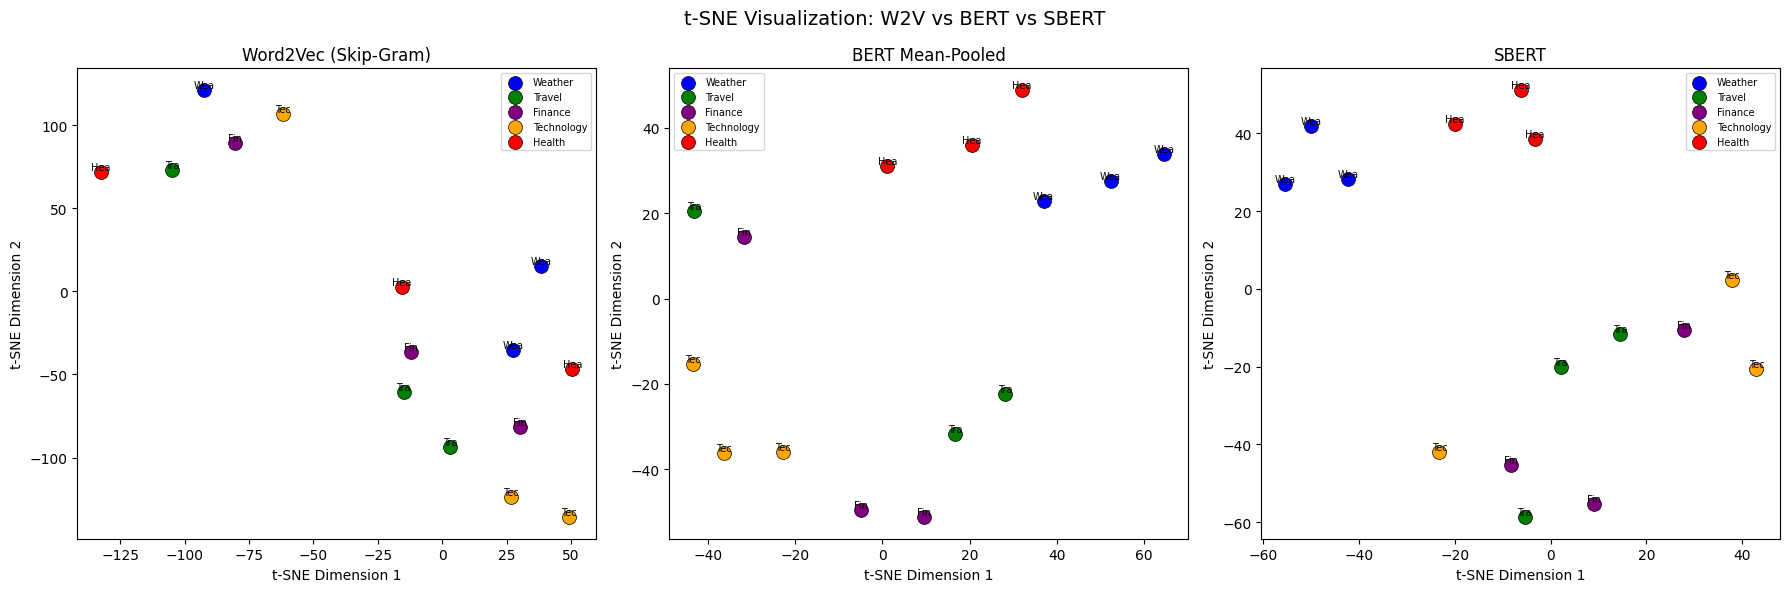

In [194]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# topic labels and colors for the 15 corpus sentences (3 per topic)
labels = ['Weather'] * 3 + ['Travel'] * 3 + ['Health'] * 3 + ['Technology'] * 3 + ['Finance'] * 3
colors = {'Weather': 'blue', 'Travel': 'green', 'Health': 'red', 'Technology': 'orange', 'Finance': 'purple'}

def get_tsne_2d(embeddings):
    # reduce with PCA first if dimensions are large enough
    n_samples, n_dims = embeddings.shape
    pca_components = min(50, n_samples - 1, n_dims)
    pca = PCA(n_components=pca_components)
    reduced = pca.fit_transform(embeddings)
    tsne = TSNE(n_components=2, perplexity=5, learning_rate='auto', init='pca', random_state=42)
    return tsne.fit_transform(reduced)

# get embeddings as numpy arrays
w2v_tsne   = get_tsne_2d(w2v_corpus_embeddings)
bert_tsne  = get_tsne_2d(bert_embeddings.numpy())
sbert_tsne = get_tsne_2d(sbert_embeddings)

# ── plot all three side by side ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, tsne_result, title in zip(
    axes,
    [w2v_tsne, bert_tsne, sbert_tsne],
    ['Word2Vec (Skip-Gram)', 'BERT Mean-Pooled', 'SBERT']
):
    for label in set(labels):
        indices = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(
            tsne_result[indices, 0],
            tsne_result[indices, 1],
            c=colors[label],
            label=label,
            s=100,
            edgecolors='black',
            linewidths=0.5
        )
        # annotate each point with a short label
        for i in indices:
            ax.annotate(label[:3], (tsne_result[i, 0], tsne_result[i, 1]),
                       fontsize=7, ha='center', va='bottom')

    ax.set_title(title)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.legend(fontsize=7)

plt.suptitle("t-SNE Visualization: W2V vs BERT vs SBERT", fontsize=14)
plt.tight_layout()
plt.show()

### Discussion of results for the presentation: What are the limits of this approach?

**AI Use:** Claude  
*Prompt:* Discussion of results for the presentation: What are the limits of this approach? Sbert was the best probably because it is the most finetuned of all the models, limits: only words in little data are trained, ground truth manually defineed, small training data size, no feedback for ranking -> use my answer and formulate it nicer

**Results Discussion**

SBERT performed best across all metrics, Precision@k, Recall@k, and MRR, most likely because it is the most fine-tuned of the three models. Unlike BERT mean-pooled, which applies general-purpose contextual embeddings, and Word2Vec, which operates purely at the word level, SBERT was specifically trained on sentence-level similarity tasks, making it naturally better suited for retrieval.

**Limits of this Approach**

**Small and limited training data** - Word2Vec was trained on only 15 sentences, meaning only the words present in those sentences are learned. Any word outside this tiny vocabulary is silently skipped, which can result in weak or incomplete query embeddings.

**Manually defined ground truth** - the relevance labels were assigned by hand, which introduces subjectivity. Different annotators might disagree on what counts as a relevant match, making the evaluation less objective.

**Small corpus size** - with only 15 documents, the evaluation has very limited statistical meaning. Real retrieval systems are tested on thousands of documents to produce reliable metrics.

**No feedback or re-ranking** - the system returns a static ranked list with no mechanism to incorporate user feedback. Real search engines iteratively refine results based on user interactions, which significantly improves retrieval quality over time.

# Exercise 3 Text Classification with various Embeddings
In this exercise, you will classify SMS messages as spam or ham using multiple embedding
methods.  
Embedding Methods:  
• BERT [CLS] token embedding  
• BERT mean-pooled token embeddings  
• Word2Vec trained on the dataset  
You will train a classifier of your choice on each embedding type and compare performance
using classification reports, confusion matrices, and qualitative error analysis. Additionally
research online when to use the [CLS] token and when to use mean-pooling.  
### Deliverables:
• Embedding extraction code  
• Classifier training and evaluation  
• A comparison of all methods to present in the exercise.  
• Analysis on [CLS] token vs mean-pooling.  

### Imports

In [195]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [196]:
# BERT imports
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

In [197]:
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

### Load Dataset

In [199]:
# read csv into dataframe
df = pd.read_csv('train.csv')

**AI Use:** Claude  
*Prompt:* Tell me how to do the split in the best way

In [200]:
# convert labels to binary
df['label_bin'] = df['label']
print(df['label'].value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    df['sms'].tolist(), df['label_bin'].tolist(),
    test_size=0.2, random_state=42,
    stratify=df['label_bin']
)

print("Train label distribution:", pd.Series(y_train).value_counts().to_dict())
print("Test label distribution: ", pd.Series(y_test).value_counts().to_dict())

label
0    4827
1     747
Name: count, dtype: int64
Train label distribution: {0: 3861, 1: 598}
Test label distribution:  {0: 966, 1: 149}


### BERT [CLS] token embedding   

-> 
for all the models I reused Exercise 2

In [161]:
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased')
bert_model.eval()

def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = bert_tokenizer(batch, padding=True, truncation=True,
                                  max_length=128, return_tensors='pt')
        with torch.no_grad():
            output = bert_model(**encoded)
        # [CLS] token is always the first token
        cls_embeddings = output.last_hidden_state[:, 0, :].numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

print("Extracting CLS embeddings...")
X_train_cls = get_cls_embeddings(X_train)
X_test_cls  = get_cls_embeddings(X_test)
print("CLS embeddings shape:", X_train_cls.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting CLS embeddings...
CLS embeddings shape: (4459, 768)


### BERT mean-pooled token embeddings  

In [202]:
def get_meanpool_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = bert_tokenizer(batch, padding=True, truncation=True,
                                  max_length=128, return_tensors='pt')
        with torch.no_grad():
            output = bert_model(**encoded)
        embeddings = mean_pooling(output, encoded['attention_mask']).numpy()
        all_embeddings.append(embeddings)
    return np.vstack(all_embeddings)

print("Extracting mean-pooled embeddings...")
X_train_mean = get_meanpool_embeddings(X_train)
X_test_mean  = get_meanpool_embeddings(X_test)
print("Mean-pooled embeddings shape:", X_train_mean.shape)

Extracting mean-pooled embeddings...
Mean-pooled embeddings shape: (4459, 768)


### Word2Vec trained on the dataset

In [203]:
train_tokens = [[w.lower() for w in word_tokenize(s)] for s in X_train]
w2v_sms_model = Word2Vec(train_tokens, vector_size=100, window=5, min_count=1, sg=1)

def get_w2v_embeddings(texts):
    embeddings = []
    for text in texts:
        words = [w.lower() for w in word_tokenize(text)]
        vecs = [w2v_sms_model.wv[w] for w in words if w in w2v_sms_model.wv]
        if vecs:
            embeddings.append(np.mean(vecs, axis=0))
        else:
            embeddings.append(np.zeros(100))
    return np.array(embeddings)

X_train_w2v = get_w2v_embeddings(X_train)
X_test_w2v  = get_w2v_embeddings(X_test)
print("W2V embeddings shape:", X_train_w2v.shape)

W2V embeddings shape: (4459, 100)


**AI Use:** Claude  
*Prompt:* tell me how to evaluate the performance using Logistic regression and do a classification report, a confusion matrix


  BERT [CLS]
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.94      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



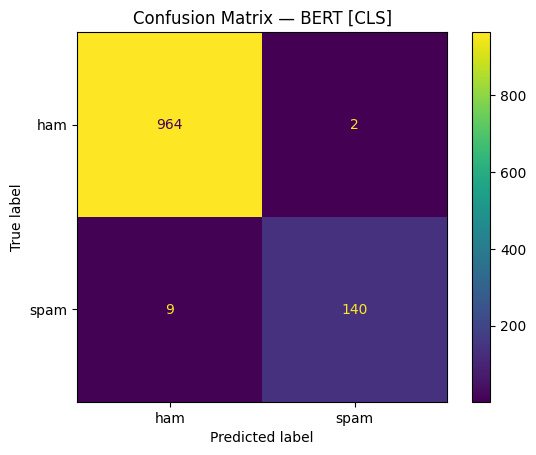


  BERT Mean-Pooled
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



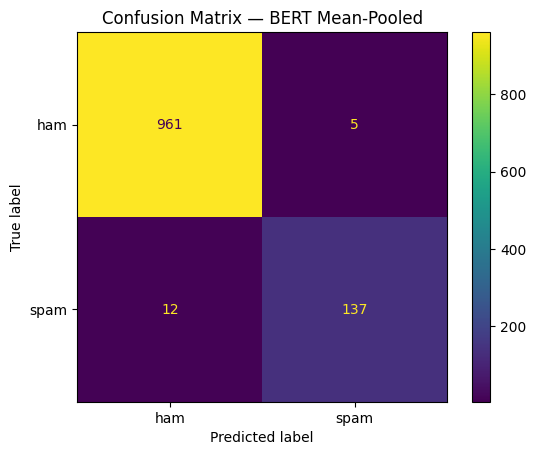


  Word2Vec
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       966
        spam       0.94      0.80      0.86       149

    accuracy                           0.97      1115
   macro avg       0.95      0.90      0.92      1115
weighted avg       0.97      0.97      0.96      1115



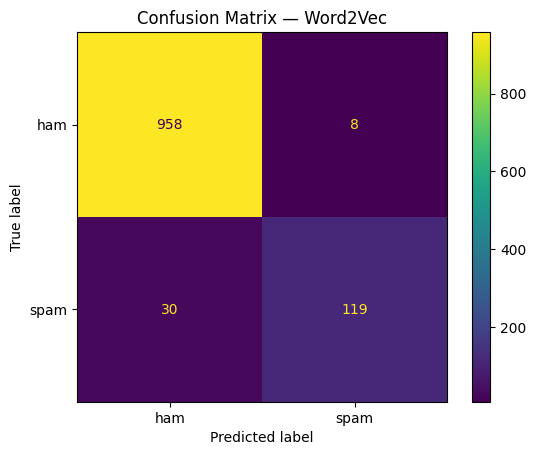

In [204]:
def train_and_evaluate(X_train, X_test, y_train, y_test, name):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    return clf

clf_cls  = train_and_evaluate(X_train_cls,  X_test_cls,  y_train, y_test, "BERT [CLS]")
clf_mean = train_and_evaluate(X_train_mean, X_test_mean, y_train, y_test, "BERT Mean-Pooled")
clf_w2v  = train_and_evaluate(X_train_w2v,  X_test_w2v,  y_train, y_test, "Word2Vec")

In [205]:
def show_errors(X_test_texts, X_test_emb, clf, name, n=5):
    y_pred = clf.predict(X_test_emb)
    errors = [(X_test_texts[i], y_test[i], y_pred[i])
              for i in range(len(y_test)) if y_test[i] != y_pred[i]]

    print(f"\nMisclassified examples — {name} (showing {n}):")
    for text, true, pred in errors[:n]:
        print(f"  TRUE: {'spam' if true else 'ham'} | PRED: {'spam' if pred else 'ham'}")
        print(f"  TEXT: {text}\n")

show_errors(X_test, X_test_cls,  clf_cls,  "BERT [CLS]")
show_errors(X_test, X_test_mean, clf_mean, "BERT Mean-Pooled")
show_errors(X_test, X_test_w2v,  clf_w2v,  "Word2Vec")


Misclassified examples — BERT [CLS] (showing 5):
  TRUE: ham | PRED: spam
  TEXT: The search 4 happiness is 1 of d main sources of unhappiness! Accept life the way it comes! U will find happiness in every moment u live.


  TRUE: spam | PRED: ham
  TEXT: Bought one ringtone and now getting texts costing 3 pound offering more tones etc


  TRUE: spam | PRED: ham
  TEXT: ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringing in a real breath of sunshine.


  TRUE: spam | PRED: ham
  TEXT: sexy sexy cum and text me im wet and warm and ready for some porn! u up for some fun? THIS MSG IS FREE RECD MSGS 150P INC VAT 2 CANCEL TEXT STOP


  TRUE: spam | PRED: ham
  TEXT: Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?



Misclassified examples — BERT Mean-Pooled (showing 5):
  TRUE: spam | PRED: ham
  TEXT: Hi ya babe x u 4goten bout me?' scammers getting smart..Though th

**AI Use:** Claude  
*Prompt:* make a table to summarize the performance of the models

In [206]:
methods = {
    "BERT [CLS]":       (clf_cls,  X_test_cls),
    "BERT Mean-Pooled": (clf_mean, X_test_mean),
    "Word2Vec":         (clf_w2v,  X_test_w2v),
}

rows = []
for name, (clf, X_test_emb) in methods.items():
    y_pred = clf.predict(X_test_emb)
    rows.append({
        "Method":    name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "F1 (macro)": round(f1_score(y_test, y_pred, average='macro'), 4),
        "F1 (spam)":  round(f1_score(y_test, y_pred, pos_label=1, average='binary'), 4),
    })

summary_df = pd.DataFrame(rows).set_index("Method")
print(summary_df.to_string())

                  Accuracy  F1 (macro)  F1 (spam)
Method                                           
BERT [CLS]          0.9901      0.9783     0.9622
BERT Mean-Pooled    0.9848      0.9664     0.9416
Word2Vec            0.9659      0.9214     0.8623


### When to use the [CLS] token and when to use mean-pooling
*Source:* https://zilliz.com/ai-faq/how-does-the-choice-of-pooling-strategy-mean-pooling-vs-using-the-cls-token-potentially-affect-the-quality-of-the-embeddings-and-the-speed-of-computation

**Embedding Quality:**
For comprehensive understanding mean pooling outperforms [CLS]. In mean pooling the token vectors get averaged and the noise is smoothed, whereas in [CLS] the tokens embedding is optimized for classification during the pre-training step and not the general semantic representation. 
   
CLS can be more effective if the model is fine tuned on a task training the token explicitly. 

**Computation Speed**
In CLS no aggregation is needed which avoids the overhead of summing and dividing vectors, making it a lot faster. Parallelization makes this difference in speed negligible. A much bigger difference can be noticed in the memory usage. Storing all token embeddings for mean pooling is exhausting our resources, making CLS more suitable for memory constraint environments.  

# Exercise 4 Code Classification with BERT Embeddings
This exercise you will classify short code snippets using contextual embeddings. As calculating the embeddings is quite resource intensive you are provided the embeddings and the base
notebook on eLearning. You will:  
• Load and preprocess a labeled code dataset  
• Generate BERT embeddings (already provided to you to save time)  
• Train a traditional classifier (eg. LogisticRegression from sklearn)  
• Evaluate with confusion matrix and classification report  
• Prepare for the presentation in the exercise, what worked well / didn’t work well and why
that might be the case.  
### Deliverables:  
Notebook with embedding extraction, model training, evaluation, and analysis of the findings.

### Imports

In [207]:
from transformers import BertTokenizer, BertModel
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.decomposition import PCA

### Load Dataset and Prepocess
-> from given notebook


In [208]:
import pyarrow.feather as feather

df = feather.read_table('embeddings.feather').to_pandas()
df.head(4)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X760,X761,X762,X763,X764,X765,X766,X767,X768,language
0,-0.173793,-0.325611,0.260916,-0.090371,-0.003099,-0.689703,0.169172,0.161007,-0.156974,-0.634382,...,-0.444923,-0.085975,-0.347440,-0.071519,0.916738,0.032165,-0.395401,-0.151372,0.753215,Markdown
1,-0.551476,0.114461,-0.156257,-0.095483,-0.491529,-0.717104,0.610803,-0.087726,0.567443,-0.527859,...,-0.543031,-0.006777,-0.379004,-0.076810,0.353173,-0.265057,-0.592026,-0.525372,0.525150,XML
2,-0.340610,0.312390,-0.245592,-0.390323,0.570317,-0.937024,0.177742,1.024876,0.044157,0.052844,...,-0.521548,0.697367,-0.445880,-0.071272,0.251338,0.437460,-0.264365,-0.438744,0.614954,Text
3,0.030533,-0.629911,-0.322072,0.253435,-0.335275,-0.971226,0.205228,0.110962,0.084097,-0.191846,...,-0.457321,0.029477,-0.645487,-0.347078,1.028343,-0.073201,-0.468006,-0.304346,0.600119,Markdown


**AI Use:** Claude  
*Prompt:* show me how I can seperate the feature matric X and the target vector y

In [209]:
# Separate feature matrix X and target vector y
feature_cols = [c for c in df.columns if c.startswith('X')]
X = df[feature_cols].values.astype(np.float32)
y = df['language'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Labels shape:         {y.shape}')
print(f'Unique languages: {np.unique(y)}')

Feature matrix shape: (86151, 768)
Labels shape:         (86151,)
Unique languages: ['Assembly' 'Batchfile' 'C' 'C#' 'C++' 'CSS' 'CSV' 'Clojure'
 'CoffeeScript' 'Dart' 'Diff' 'Dockerfile' 'ERB' 'Elixir' 'Erlang' 'GAS'
 'GLSL' 'Go' 'Gradle' 'Graphviz (DOT)' 'Groovy' 'HTML' 'Haskell' 'INI'
 'JSON' 'Java' 'Javascript' 'Julia' 'Jupyter Notebook' 'Kotlin' 'LLVM'
 'Less' 'Lisp' 'Lua' 'MIR' 'Makefile' 'Markdown' 'Org' 'PHP' 'Pascal'
 'PowerShell' 'Prolog' 'Protocol Buffer' 'Puppet' 'Python' 'Q#' 'RDoc'
 'Ruby' 'Rust' 'SQL' 'SVG' 'Scala' 'Scheme' 'Shell' 'SourcePawn' 'Swift'
 'TOML' 'Text' 'XML' 'YAML']


**AI Use:** Claude  
*Prompt:* how can I remove classes with too few samples to fix this error: 'pasted error'

In [211]:
# Remove classes with fewer than 2 samples (can't stratify otherwise)
from collections import Counter

counts = Counter(y)
valid_classes = {cls for cls, cnt in counts.items() if cnt >= 2}
removed = {cls: cnt for cls, cnt in counts.items() if cnt < 2}
print(f"Removed {len(removed)} rare classes: {removed}")

mask = np.array([label in valid_classes for label in y])
X_filtered, y_filtered = X[mask], y[mask]
print(f"Remaining: {X_filtered.shape[0]} samples, {len(valid_classes)} classes")

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)
print(f'Train size: {X_train.shape[0]}')
print(f'Test  size: {X_test.shape[0]}')

Removed 0 rare classes: {}
Remaining: 86151 samples, 60 classes
Train size: 68920
Test  size: 17231


### Train a traditional classifier (eg. LogisticRegression from sklearn)  
*Source:* https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/


In [212]:
clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Evaluate with confusion matrix and classification report  

In [213]:
# Classification report
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('Classification Report:')
print(classification_report(y_test, y_pred, digits=3))

Classification Report:
                  precision    recall  f1-score   support

        Assembly      1.000     0.889     0.941         9
       Batchfile      1.000     0.889     0.941         9
               C      0.732     0.600     0.660       205
              C#      0.994     0.998     0.996      2000
             C++      0.801     0.814     0.807       306
             CSS      0.907     0.750     0.821        52
             CSV      1.000     0.500     0.667         4
         Clojure      0.923     0.960     0.941        25
    CoffeeScript      1.000     0.333     0.500         3
            Dart      0.969     0.983     0.976      3069
            Diff      0.969     0.940     0.954       166
      Dockerfile      0.982     1.000     0.991        54
             ERB      0.881     0.899     0.890        99
          Elixir      0.897     0.906     0.901       106
          Erlang      0.900     0.900     0.900        10
             GAS      1.000     0.991     0.995 

**AI Use:** Claude  
*Prompt:* write me the code for a nice confusion matrx

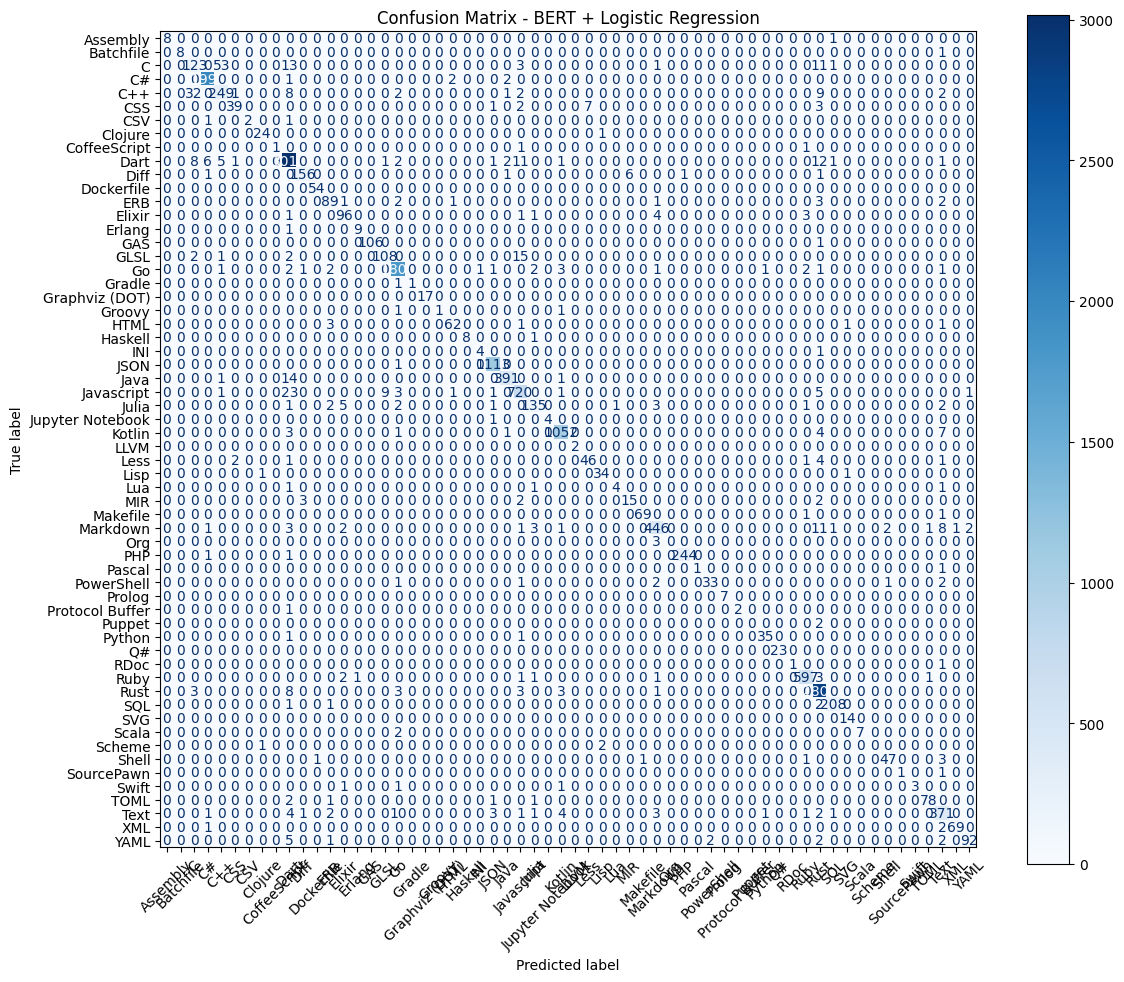

In [214]:
# Confusion matrix
labels = np.unique(y)
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix - BERT + Logistic Regression', fontsize=12)
plt.tight_layout()
plt.show()

**AI Use:** Claude  
*Prompt:* show me how to make a nice visualization using pca

Explained variance ratio: PC1=0.237, PC2=0.159


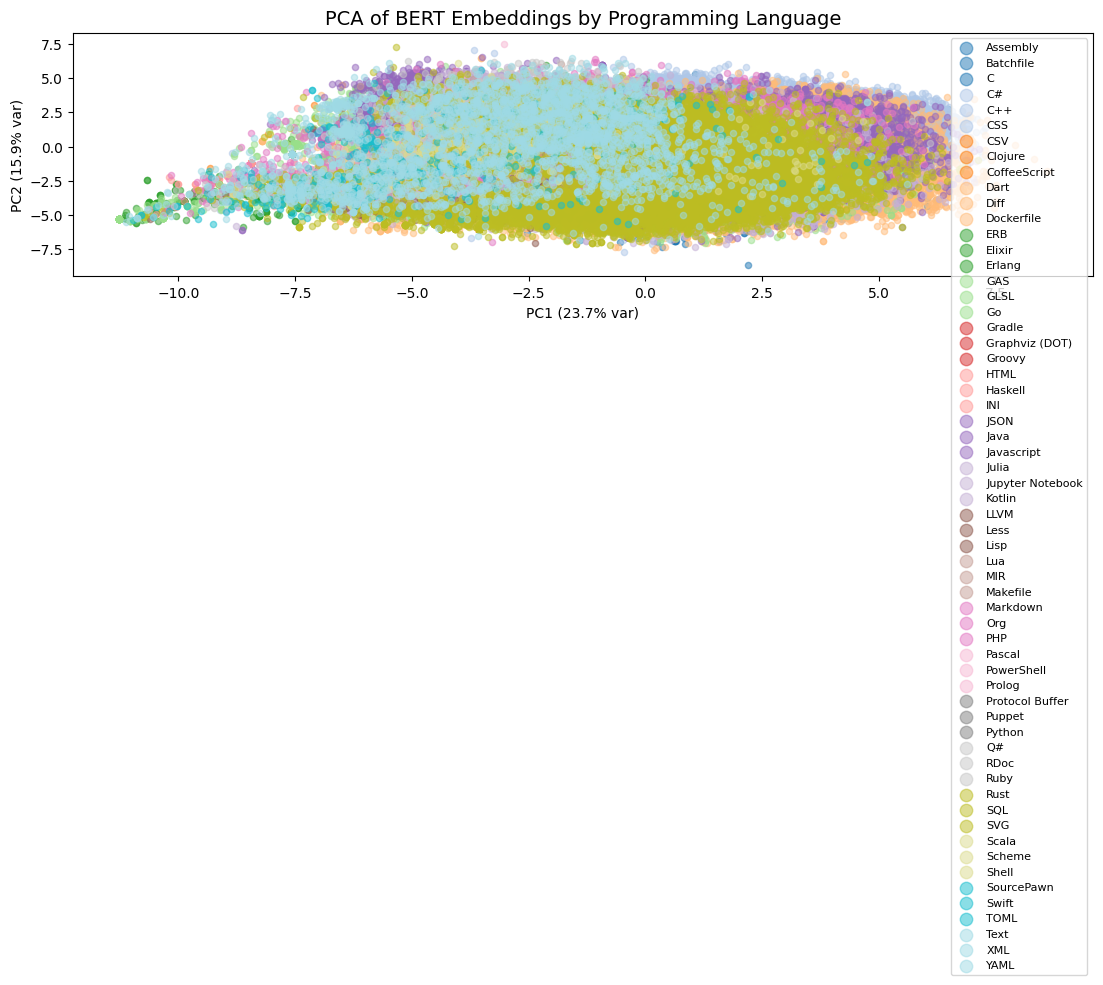

In [215]:
# Visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

unique_langs = np.unique(y)
palette = plt.cm.get_cmap('tab20', len(unique_langs))

fig, ax = plt.subplots(figsize=(11, 7))
for i, lang in enumerate(unique_langs):
    mask = y == lang
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=lang, alpha=0.5, s=20, color=palette(i))

ax.set_title('PCA of BERT Embeddings by Programming Language', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(loc='best', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

### Prepare for the presentation in the exercise, what worked well / didn’t work well and why that might be the case. 

**AI Use:** Claude  
*Prompt:* use the following and formulate it nicer for this question what worked well / didn’t work well and why that might be the case: what worked well: BERT seperated the different languages quite well, even without finetuning, logistic regression was a good fit
what did not work well: pretraining was done on natural language- makes it harder to seperate, long code files are cut off- might discard important information

##### What worked well
**BERT separated the languages well without any fine-tuning.** The [CLS] embeddings formed distinct enough clusters that a simple Logistic Regression could draw clean boundaries between most languages - demonstrating how powerful general-purpose contextual embeddings are even outside their original domain.

**Logistic Regression was a natural fit** for this high-dimensional embedding space, achieving strong accuracy with minimal complexity.


##### What didn't work as well

**Pre-training on natural language is a mismatch for code.** Since bert-base-uncased was never exposed to code during pre-training, it lacks understanding of code-specific syntax and structure - making it harder to separate languages that look visually similar, like JavaScript and TypeScript or C and C++.

**Long files are silently truncated at 512 tokens.** This means the classifier may never see some of the most distinctive parts of a snippet - such as import statements or class definitions - potentially discarding exactly the information that would make a language unambiguous.